# Description

This notebook the TPC ADC distribution histograms produced by the RawWaveform (???) analyzer module
 and calculates conservative TP rate estimates based on the ADC distribution quantiles, and vice versa.

# Setup

In [14]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Imports

In [15]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
import os
from pathlib import Path
import dunetrg.data.workspace as workspace
# import tpvalidator.utils as utils
import dunetrg.analysis.snn as snn
import mplhep as hep
import matplotlib.pyplot as plt
import hist

from rich import print
import rich
rich.get_console().is_jupyter = False

from dunetrg.analysis.histograms import hist_stats, quantiles


## Code

In [16]:
def uproot_to_hist(h):
    hh = h.to_hist()
    hh.name = h.name
    hh.label = h.title
    return hh

In [17]:
def print_quantiles_table(h, p: dict):

    from rich.table import Table
    
    prob=np.array(list(p.values()))

    # y=0.
    # xq=np.array([0.]*len(prob))

    xq = quantiles(h, prob)
    h_mean, h_std = hist_stats(h)[0]
    
    # h.GetQuantiles(len(prob),xq,prob)

    # cols = [str(i) for i in range(len(prob)+1)]
    # cols = ['']+list(p.keys())
    t = Table(title=h.label)
    t.add_column("value", min_width=20)
    for k in p:
        t.add_column(k)
    # h_std = h.GetStdDev()
    # t = Table(*cols, title=h.GetName())
    t.add_row(*(['input prob']+ [f"{1-p:.3e}" for p in prob]))
    t.add_row(*(['x vals (adcs)']+ [f"{x:.2f}" for x in xq]))
    t.add_row(*(['dist from mean (adcs)']+ [f"{x:.2f}" for x in (xq-xq[0])]))
    t.add_row(*(['dist from mean (68% units)', '-']+ [f"{x:.2f}" for x in (xq-xq[0])[1:]/(xq[1]-xq[0])]))
    t.add_row(*(['dist from mean (std)', '-']+ [f"{x:.2f}" for x in (xq-xq[0])[1:]/h_std]))


    c = rich.get_console()
    c.is_jupyter = True
    c.width = 200

    print(t)

In [18]:

def plot_adc_hist_right_tail(h: hist.Hist, thr: int, win_size: int) -> plt.Figure:
    """Plots histogram, its stats highlighting the right tail

    Args:
        h (hist.Hist): The histogram to plot
        thr (int): Threshold
        win_size (int): display window size

    Returns:
        plt.Figure: Resulting figure
    """

    stat_x = 0.95
    stat_y = 0.95
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)

    fig, ax = plt.subplots()

    h_mean, h_std = hist_stats(h)[0]
    x_axis = h.axes[0]

    m = x_axis.index(h_mean)
    p = x_axis.index(h_mean+thr)

    # Histogram, line only
    hep.histplot(h[m-win_size:m+win_size], label="all adcs", linewidth=2, yerr=False, ax=ax)


    # Histogram
    # Make a copy and zero all bins below threshold
    hh = h.copy()
    hh[:p] = 0

    hep.histplot(hh[m-win_size:m+win_size], label=f"adcs > {h_mean+thr:.0f}", linewidth=2, yerr=False, ax=ax, histtype='fill')


    textstr = '\n'.join((
        f'$\\mu={h_mean:.2f}$',
        f'$\\sigma={h_std:.2f}$'))

    # place a text box in top center in axes coords
    ax.text(stat_x, stat_y, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    

    # Decorations
    ax.set_title("Noise Hist, plane X")
    ax.set_xlabel("adc")
    ax.set_ylabel("counts")
    ax.set_yscale("log")
    ax.legend()

    fig.tight_layout()

    return fig

# Argon 39

## Load ADC mean and standard deviation from wafevorm histograms

In [19]:
import dunetrg.data.datacatalogue as dsl

# dataset_name = 'radbkg'
dataset_name = 'ar39_5e_00'
datasets = dsl.load('vd/1x8x14/3sig', [dataset_name])
ar39_ws=datasets[dataset_name]

Loading ar39_5e_00


Dataset 'ar39_5e_00': 5 events
{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'Ar39GenInLAr']],
    'tpg': {'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {'threshold_tpg_plane0': 27, 'threshold_tpg_plane1': 27, 'threshold_tpg_plane2': 27, 'tool': 'TPAlgTPCSimpleThreshold'}},
    'detector_properties': {'readout_window': 8500}
}


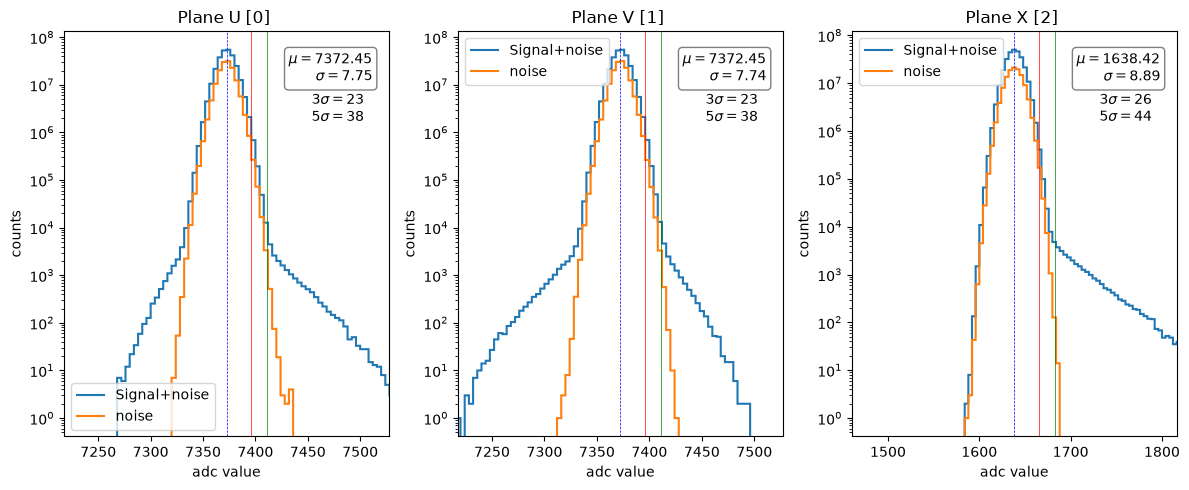

In [20]:
fig = snn.draw_signal_and_noise_adc_distros(ar39_ws)
fig.tight_layout()

## Starting here

In [21]:
h_adc_u = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsPlaneU'])
h_adc_v = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsPlaneV'])
h_adc_x = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsPlaneX'])

h_adc_noise_u = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsNoisePlaneU'])
h_adc_noise_v = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsNoisePlaneV'])
h_adc_noise_x = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsNoisePlaneX'])

In [22]:
print(hist_stats(h_adc_noise_x))
print(hist_stats(h_adc_noise_u))
print(hist_stats(h_adc_noise_v))

[(1638.4190275424357, 8.890358364548693)]
[(7372.453015445632, 7.749727998082626)]
[(7372.4530182443805, 7.737304256101686)]


In [23]:
def calc_pval_noise(h, rate_noise_tps = 2):
    sampl_period = 0.5e-6 # s
    # num_noise = int(h.GetEntries())
    num_noise = int(h.integrate(0))
    t_sampl = num_noise*sampl_period # s
    n_exp_noise_tps = rate_noise_tps*t_sampl
    p_val_noise_tps = n_exp_noise_tps/num_noise
    quantile = 1-p_val_noise_tps


    #-----
    print(f"---hist '{h.label}'---" )
    print(f"num noise adcs = {num_noise}")
    print(f"sampling period = {t_sampl} s")
    print(f"target noise rate = {rate_noise_tps} Hz")
    print(f"num expected noise adcs = {n_exp_noise_tps}")
    print(f"p_val_noise = {p_val_noise_tps}")
    print(f"quantile = {quantile}")
    print()



calc_pval_noise(h_adc_noise_u, 100)
calc_pval_noise(h_adc_noise_v, 100)
calc_pval_noise(h_adc_noise_x, 100)

---hist 'ADCs on plane U'---
num noise adcs = 144474500
sampling period = 72.23725 s
target noise rate = 100 Hz
num expected noise adcs = 7223.725
p_val_noise = 5e-05
quantile = 0.99995

---hist 'ADCs on plane X'---
num noise adcs = 144729500
sampling period = 72.36475 s
target noise rate = 100 Hz
num expected noise adcs = 7236.475
p_val_noise = 5e-05
quantile = 0.99995

---hist 'ADCs on plane X'---
num noise adcs = 118090500
sampling period = 59.045249999999996 s
target noise rate = 100 Hz
num expected noise adcs = 5904.525
p_val_noise = 4.9999999999999996e-05
quantile = 0.99995



In [24]:

prob=np.array([0.5, 0.841, 0.977, 0.998, 0.9999685, 0.99999985, 0.9999974370002747, 0.999999, 0.999995, 0.99995])

prob_d = {
    'mean':  0.5,
    '1-sig': 0.841,
    '2-sig': 0.977, 
    '3-sig': 0.998, 
    '4-sig': 0.9999685, 
    '5-sig': 0.99999985, 
    'coll-ref': 0.9999974370002747, 
    '2 Hz': 0.999999,
    '10 Hz': 0.999995,
    '100 Hz': 0.99995
}

print_quantiles_table(h_adc_noise_x, prob_d)
print_quantiles_table(h_adc_noise_u, prob_d)
print_quantiles_table(h_adc_noise_x, prob_d)


                                                                   ADCs on plane X                                                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ value                      ┃ mean      ┃ 1-sig     ┃ 2-sig     ┃ 3-sig     ┃ 4-sig     ┃ 5-sig     ┃ coll-ref  ┃ 2 Hz      ┃ 10 Hz     ┃ 100 Hz    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━┩
│ input prob                 │ 5.000e-01 │ 1.590e-01 │ 2.300e-02 │ 2.000e-03 │ 3.150e-05 │ 1.500e-07 │ 2.563e-06 │ 1.000e-06 │ 5.000e-06 │ 5.000e-05 │
│ x vals (adcs)              │ 1638.41   │ 1647.34   │ 1656.02   │ 1663.88   │ 1674.63   │ 1683.88   │ 1679.39   │ 1680.72   │ 1678.30   │ 1673.45   │
│ dist from mean (adcs)      │ 0.00      │ 8.93      │ 17.61     │ 25.47     │ 36.22     │ 45.47     │ 40.98     │ 42.31     │ 39.89     │ 35.04     │
│ dist from mean (68% units) │ -         │ 1.00      │ 1.97      │ 2.85      │ 4.05      │ 5.09      │ 4.59      │ 4.74      │ 4.46      │ 3.92      │
│ dist from mean (std)       │ -         │ 1.00      │ 1.98      │ 2.87      │ 4.07      │ 5.11      │ 4.61      │ 4.76      │ 4.49      │ 3.94      │
└────────────────────────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘

                                                                   ADCs on plane U                                                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ value                      ┃ mean      ┃ 1-sig     ┃ 2-sig     ┃ 3-sig     ┃ 4-sig     ┃ 5-sig     ┃ coll-ref  ┃ 2 Hz      ┃ 10 Hz     ┃ 100 Hz    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━┩
│ input prob                 │ 5.000e-01 │ 1.590e-01 │ 2.300e-02 │ 2.000e-03 │ 3.150e-05 │ 1.500e-07 │ 2.563e-06 │ 1.000e-06 │ 5.000e-06 │ 5.000e-05 │
│ x vals (adcs)              │ 7372.47   │ 7379.78   │ 7388.40   │ 7397.07   │ 7407.86   │ 7421.33   │ 7413.94   │ 7415.68   │ 7411.88   │ 7407.22   │
│ dist from mean (adcs)      │ 0.00      │ 7.31      │ 15.93     │ 24.60     │ 35.39     │ 48.86     │ 41.47     │ 43.21     │ 39.41     │ 34.75     │
│ dist from mean (68% units) │ -         │ 1.00      │ 2.18      │ 3.37      │ 4.84      │ 6.69      │ 5.67      │ 5.91      │ 5.39      │ 4.75      │
│ dist from mean (std)       │ -         │ 0.94      │ 2.06      │ 3.17      │ 4.57      │ 6.31      │ 5.35      │ 5.58      │ 5.09      │ 4.48      │
└────────────────────────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘

                                                                   ADCs on plane X                                                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ value                      ┃ mean      ┃ 1-sig     ┃ 2-sig     ┃ 3-sig     ┃ 4-sig     ┃ 5-sig     ┃ coll-ref  ┃ 2 Hz      ┃ 10 Hz     ┃ 100 Hz    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━┩
│ input prob                 │ 5.000e-01 │ 1.590e-01 │ 2.300e-02 │ 2.000e-03 │ 3.150e-05 │ 1.500e-07 │ 2.563e-06 │ 1.000e-06 │ 5.000e-06 │ 5.000e-05 │
│ x vals (adcs)              │ 1638.41   │ 1647.34   │ 1656.02   │ 1663.88   │ 1674.63   │ 1683.88   │ 1679.39   │ 1680.72   │ 1678.30   │ 1673.45   │
│ dist from mean (adcs)      │ 0.00      │ 8.93      │ 17.61     │ 25.47     │ 36.22     │ 45.47     │ 40.98     │ 42.31     │ 39.89     │ 35.04     │
│ dist from mean (68% units) │ -         │ 1.00      │ 1.97      │ 2.85      │ 4.05      │ 5.09      │ 4.59      │ 4.74      │ 4.46      │ 3.92      │
│ dist from mean (std)       │ -         │ 1.00      │ 1.98      │ 2.87      │ 4.07      │ 5.11      │ 4.61      │ 4.76      │ 4.49      │ 3.94      │
└────────────────────────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘

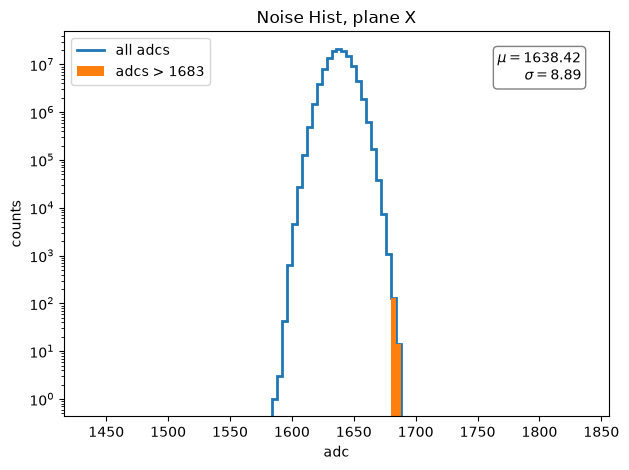

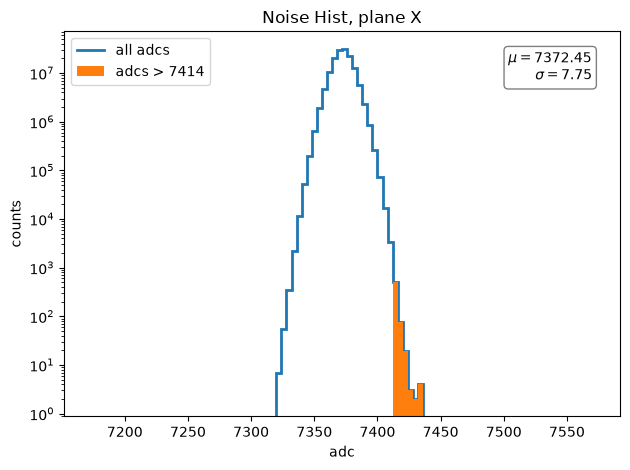

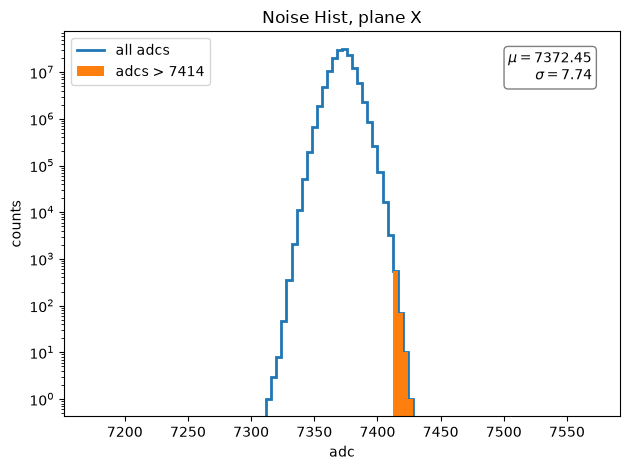

In [25]:
_ = plot_adc_hist_right_tail(h_adc_noise_x, 45, 50)
_ = plot_adc_hist_right_tail(h_adc_noise_u, 42, 50)
_ = plot_adc_hist_right_tail(h_adc_noise_v, 42, 50)


In [26]:
from dunetrg.analysis.notebook import stop

stop("Stop here")

StopExecution: Stop here

# Ar39 - Pre-production


In [ ]:
dataset_info = {
    'readout_window' : 8500
}

# TODO(migration): 'vd/pre_prod' not found under DTRG_DATA_ROOT; nearest match is
# vd/1x8x6/pre_prod/anatree_vd_ar39_hist.root (this notebook is marked "Outdated").
ar39_root_file = Path(os.environ['DTRG_DATA_ROOT']) / 'vd/pre_prod/anatree_vd_ar39_hist.root'
ar39_wf_file = Path(os.environ['DTRG_DATA_ROOT']) / 'vd/pre_prod/rawdigits/trigger_digits_hists_detsim_vd_ar39.root'

with temporary_log_level(workspace.TriggerPrimitivesWorkspace._log, logging.INFO):
    ar39_ws = workspace.TriggerPrimitivesWorkspace(ar39_root_file, dataset_info=dataset_info)

print(ar39_ws.info)
ar39_ws.add_rawdigits(str(ar39_wf_file))
fig = snn.draw_signal_and_noise_adc_distros(ar39_ws)
fig.tight_layout()

NameError: name 'temporary_log_level' is not defined

In [ ]:
h_adc_u = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsPlaneU'])
h_adc_v = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsPlaneV'])
h_adc_x = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsPlaneX'])

h_adc_noise_u = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsNoisePlaneU'])
h_adc_noise_v = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsNoisePlaneV'])
h_adc_noise_x = uproot_to_hist(ar39_ws.rawdigits_hists['ADCsNoisePlaneX'])

In [ ]:
print(hist_mean_std(h_adc_noise_x))
print(hist_mean_std(h_adc_noise_u))
print(hist_mean_std(h_adc_noise_v))

In [ ]:
def calc_pval_noise(h, rate_noise_tps = 2):
    sampl_period = 0.5e-6 # s
    # num_noise = int(h.GetEntries())
    num_noise = int(h.integrate(0))
    t_sampl = num_noise*sampl_period # s
    n_exp_noise_tps = rate_noise_tps*t_sampl
    p_val_noise_tps = n_exp_noise_tps/num_noise
    quantile = 1-p_val_noise_tps


    #-----
    print(f"""
---hist '{h.label}'---
num noise adcs = {num_noise}
sampling period = {t_sampl} s
target noise rate = {rate_noise_tps} Hz
num expected noise adcs = {n_exp_noise_tps}
p_val_noise = {p_val_noise_tps:.2e}
quantile = {quantile}
""")


calc_pval_noise(h_adc_noise_u, 100)
calc_pval_noise(h_adc_noise_v, 100)
calc_pval_noise(h_adc_noise_x, 100)

In [ ]:

prob=np.array([0.5, 0.841, 0.977, 0.998, 0.9999685, 0.99999985, 0.9999974370002747, 0.999999, 0.999995, 0.99995])

prob_d = {
    'mean':  0.5,
    '1-sig': 0.841,
    '2-sig': 0.977, 
    '3-sig': 0.998, 
    '4-sig': 0.9999685, 
    '5-sig': 0.99999985, 
    'coll-ref': 0.9999974370002747, 
    '2 Hz': 0.999999,
    '10 Hz': 0.999995,
    '100 Hz': 0.99995
}


print_quantiles_table(h_adc_noise_x, prob_d)
print_quantiles_table(h_adc_noise_u, prob_d)
print_quantiles_table(h_adc_noise_x, prob_d)


In [ ]:

_ = plot_adc_hist_right_tail(h_adc_noise_x, 45, 50)
_ = plot_adc_hist_right_tail(h_adc_noise_u, 42, 50)
_ = plot_adc_hist_right_tail(h_adc_noise_v, 42, 50)


# e-minus dataset - pre-production

In [ ]:
dataset_info = {
    'readout_window' : 8500
}

# TODO(migration): 'vd/pre_prod' not found under DTRG_DATA_ROOT; nearest match is
# vd/1x8x6/pre_prod/anatree_vd_eminus_hist.root (this notebook is marked "Outdated").
eminus_root_file = Path(os.environ['DTRG_DATA_ROOT']) / 'vd/pre_prod/anatree_vd_eminus_hist.root'
eminus_wf_file = Path(os.environ['DTRG_DATA_ROOT']) / 'vd/pre_prod/rawdigits/trigger_digits_hists_detsim_vd_eminus.root'

with temporary_log_level(workspace.TriggerPrimitivesWorkspace._log, logging.INFO):
    em_ws = workspace.TriggerPrimitivesWorkspace(eminus_root_file, dataset_info=dataset_info)

print(em_ws.info)
em_ws.add_rawdigits(str(eminus_wf_file))
fig = snn.draw_signal_and_noise_adc_distros(em_ws)
fig.tight_layout()

In [ ]:
h_adc_u = uproot_to_hist(em_ws.rawdigits_hists['ADCsPlaneU'])
h_adc_v = uproot_to_hist(em_ws.rawdigits_hists['ADCsPlaneV'])
h_adc_x = uproot_to_hist(em_ws.rawdigits_hists['ADCsPlaneX'])

h_adc_noise_u = uproot_to_hist(em_ws.rawdigits_hists['ADCsNoisePlaneU'])
h_adc_noise_v = uproot_to_hist(em_ws.rawdigits_hists['ADCsNoisePlaneV'])
h_adc_noise_x = uproot_to_hist(em_ws.rawdigits_hists['ADCsNoisePlaneX'])

In [ ]:
print(hist_mean_std(h_adc_noise_x))
print(hist_mean_std(h_adc_noise_u))
print(hist_mean_std(h_adc_noise_v))

In [ ]:
def calc_pval_noise(h, rate_noise_tps = 2):
    sampl_period = 0.5e-6 # s
    # num_noise = int(h.GetEntries())
    num_noise = int(h.integrate(0))
    t_sampl = num_noise*sampl_period # s
    n_exp_noise_tps = rate_noise_tps*t_sampl
    p_val_noise_tps = n_exp_noise_tps/num_noise
    quantile = 1-p_val_noise_tps


    #-----
    print(f"""
---hist '{h.label}'---
num noise adcs = {num_noise}
sampling period = {t_sampl} s
target noise rate = {rate_noise_tps} Hz
num expected noise adcs = {n_exp_noise_tps}
p_val_noise = {p_val_noise_tps:.2e}
quantile = {quantile}
""")


calc_pval_noise(h_adc_noise_u, 100)
calc_pval_noise(h_adc_noise_v, 100)
calc_pval_noise(h_adc_noise_x, 100)

In [ ]:

prob=np.array([0.5, 0.841, 0.977, 0.998, 0.9999685, 0.99999985, 0.9999974370002747, 0.999999, 0.999995, 0.99995])

prob_d = {
    'mean':  0.5,
    '1-sig': 0.841,
    '2-sig': 0.977, 
    '3-sig': 0.998, 
    '4-sig': 0.9999685, 
    '5-sig': 0.99999985, 
    'coll-ref': 0.9999974370002747, 
    '2 Hz': 0.999999,
    '10 Hz': 0.999995,
    '100 Hz': 0.99995
}


print_quantiles_table(h_adc_noise_x, prob_d)
print_quantiles_table(h_adc_noise_u, prob_d)
print_quantiles_table(h_adc_noise_x, prob_d)


In [ ]:

_ = plot_adc_hist_right_tail(h_adc_noise_x, 45, 50)
_ = plot_adc_hist_right_tail(h_adc_noise_u, 42, 50)
_ = plot_adc_hist_right_tail(h_adc_noise_v, 42, 50)


In [ ]:
h_adc_noise_x[1688j]